In [1]:
# First, we import everything we need. Lightweaver is typically imported as
# `lw`, but things like the library of model atoms and Fal atmospheres need to
# be imported separately.
from lightweaver.fal import Falc82
from lightweaver.rh_atoms import H_6_atom, C_atom, O_atom, Si_atom, Al_atom, \
CaII_atom, Fe_atom, He_9_atom, MgII_atom, N_atom, Na_atom, S_atom
import lightweaver as lw
import matplotlib.pyplot as plt
import time
import numpy as np

In [2]:
# Now, we define the functions that will be used in our spectral synthesise.
# First `synth_8542` which synthesises and returns the line given by an
# atmosphere.
def synth_8542(atmos, conserve, useNe, wave):
    '''
    Synthesise a spectral line for given atmosphere with different
    conditions.

    Parameters
    ----------
    atmos : lw.Atmosphere
        The atmospheric model in which to synthesise the line.
    conserve : bool
        Whether to start from LTE electron density and conserve charge, or
        simply use from the electron density present in the atomic model.
    useNe : bool
        Whether to use the electron density present in the model as the
        starting solution, or compute the LTE electron density.
    wave : np.ndarray
        Array of wavelengths over which to resynthesise the final line
        profile for muz=1.

    Returns
    -------
    ctx : lw.Context
        The Context object that was used to compute the equilibrium
        populations.
    Iwave : np.ndarray
        The intensity at muz=1 for each wavelength in `wave`.
    '''
    # Configure the atmospheric angular quadrature
    atmos.quadrature(5)
    # Configure the set of atomic models to use.
    aSet = lw.RadiativeSet([H_6_atom(), C_atom(), O_atom(), Si_atom(),
                            Al_atom(), CaII_atom(), Fe_atom(), He_9_atom(),
                            MgII_atom(), N_atom(), Na_atom(), S_atom()
                           ])
    # Set H and Ca to "active" i.e. NLTE, everything else participates as an
    # LTE background.
    aSet.set_active('H', 'Ca')
    # Compute the necessary wavelength dependent information (SpectrumConfiguration).
    spect = aSet.compute_wavelength_grid()

    # Either compute the equilibrium populations at the fixed electron density
    # provided in the model, or iterate an LTE electron density and compute the
    # corresponding equilibrium populations (SpeciesStateTable).
    if useNe:
        eqPops = aSet.compute_eq_pops(atmos)
    else:
        eqPops = aSet.iterate_lte_ne_eq_pops(atmos)

    # Configure the Context which holds the state of the simulation for the
    # backend, and provides the python interface to the backend.
    # Feel free to increase Nthreads to increase the number of threads the
    # program will use.
    ctx = lw.Context(atmos, spect, eqPops, conserveCharge=conserve, Nthreads=1)
    # Iterate the Context to convergence (using the iteration function now
    # provided by Lightweaver)
    lw.iterate_ctx_se(ctx)
    # Update the background populations based on the converged solution and
    # compute the final intensity for mu=1 on the provided wavelength grid.
    eqPops.update_lte_atoms_Hmin_pops(atmos)
    Iwave = ctx.compute_rays(wave, [atmos.muz[-1]], stokes=False)
    return ctx, Iwave



In [3]:
# The wavelength grid to output the final synthesised line on.
wave = np.linspace(853.9444, 854.9444, 1001)

In [4]:
# Load an lw.Atmosphere object containing the FAL C atmosphere with 82 points
# in depth, before synthesising the Ca II 8542 \AA line profile using:
#
# - The given electron density.
# - The electron density charge conserved from a starting LTE solution.
# - The LTE electron density.
#
# These results are then plotted.

atmosRef = Falc82()
ctxRef, IwaveRef = synth_8542(atmosRef, conserve=False, useNe=True, wave=wave)
atmosCons = Falc82()
ctxCons, IwaveCons = synth_8542(atmosCons, conserve=True, useNe=False, wave=wave)
atmosLte = Falc82()
ctx, IwaveLte = synth_8542(atmosLte, conserve=False, useNe=False, wave=wave)

-- Iteration 0:
dJ = 1.00e+00
    (Lambda iterating background)
-- Iteration 9:
dJ = 1.00e+00
    H delta = 2.9038e-01
    Ca delta = 2.3130e-01
-- Iteration 18:
dJ = 1.41e-01
    H delta = 7.3603e-02
    Ca delta = 6.8821e-02
-- Iteration 27:
dJ = 8.50e-02
    H delta = 5.0410e-02
    Ca delta = 3.4541e-02
-- Iteration 36:
dJ = 7.28e-02
    H delta = 4.3635e-02
    Ca delta = 2.3167e-02
-- Iteration 45:
dJ = 6.32e-02
    H delta = 3.4624e-02
    Ca delta = 1.5864e-02
-- Iteration 54:
dJ = 5.04e-02
    H delta = 2.5356e-02
    Ca delta = 9.7035e-03
-- Iteration 63:
dJ = 3.31e-02
    H delta = 1.8010e-02
    Ca delta = 5.1067e-03
-- Iteration 72:
dJ = 1.79e-02
    H delta = 1.0098e-02
    Ca delta = 2.3932e-03
-- Iteration 81:
dJ = 8.30e-03
    H delta = 4.7805e-03
    Ca delta = 1.0351e-03
-- Iteration 90:
dJ = 3.56e-03
    H delta = 2.0733e-03
    Ca delta = 4.3477e-04
--------------------------------------------------------------------------------
Final Iteration: 98
----------------

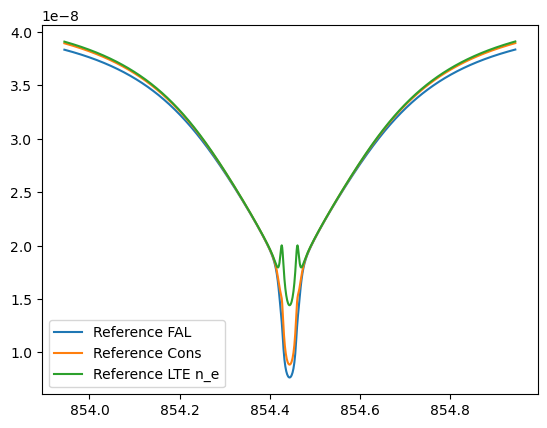

In [5]:
plt.plot(wave, IwaveRef, label='Reference FAL')
plt.plot(wave, IwaveCons, label='Reference Cons')
plt.plot(wave, IwaveLte, label='Reference LTE n_e')
plt.legend()
plt.show()